<a href="https://colab.research.google.com/github/hhaifa/a/blob/master/sigmoideML_ALGORITHME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory to where the zip file is located
import os
os.chdir('/content/drive/My Drive')  # Adjust the path if the file is in a different folder

# Unzip the file
!unzip sg11.zip -d /content/sg11

# Change directory to the unzipped content
drive.mount("/content/drive", force_remount=True)
os.chdir('/content/sg11')

# List the contents of the unzipped directory
print('Extracted files:')
print(os.listdir('.'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  sg11.zip
replace /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/144.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/144.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/154.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/164.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/174.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/184.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/194.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/204.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/214.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/224.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/234.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/244.png  
  

In [12]:
import os

path = '/content/sg11/sgmoidAI/sgmoidAI/Train/Smoid/'

if os.path.exists(path):
    print(f'The directory {path} exists.')
else:
    print(f'The directory {path} does not exist.')


The directory /content/sg11/sgmoidAI/sgmoidAI/Train/Smoid/ exists.


In [13]:
print('total training Healthy images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Train/Healthy/')))
print('total training Sigmoid images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Train/Smoid/')))
print('total validation sgmoid images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Val/Smoid')))
print('total validation Healthy images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Val/Healthy')))
print('total test Healthy images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Test/Healthy')))
print('total test Sigmoid images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Test/Sigmoid')))

total training Healthy images: 516
total training Sigmoid images: 516
total validation sgmoid images: 111
total validation Healthy images: 111
total test Healthy images: 110
total test Sigmoid images: 110


In [14]:
import os

# Define paths to your dataset directories
train_dir = '/content/sg11/sgmoidAI/sgmoidAI/Train/'
validation_dir = '/content/sg11/sgmoidAI/sgmoidAI/Val/'

# Check if directories exist
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Error: The training directory '{train_dir}' does not exist. Please verify the path.")
if not os.path.exists(validation_dir):
    raise FileNotFoundError(f"Error: The validation directory '{validation_dir}' does not exist. Please verify the path.")

print("Both directories exist. Proceeding with further steps.")


Both directories exist. Proceeding with further steps.


Total training Healthy images: 516
Total training Smoid images: 516
Total validation Healthy images: 111
Total validation Smoid images: 111
Total test images: 2
Total images: 1254
label
Smoid      627
Healthy    627
Name: count, dtype: int64


<>:142: SyntaxWarning: invalid escape sequence '\('
<>:142: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_1655/16153273.py:142: SyntaxWarning: invalid escape sequence '\('
  target_img = df[df['path'].str.contains('patient \(95\)C.jpg')]


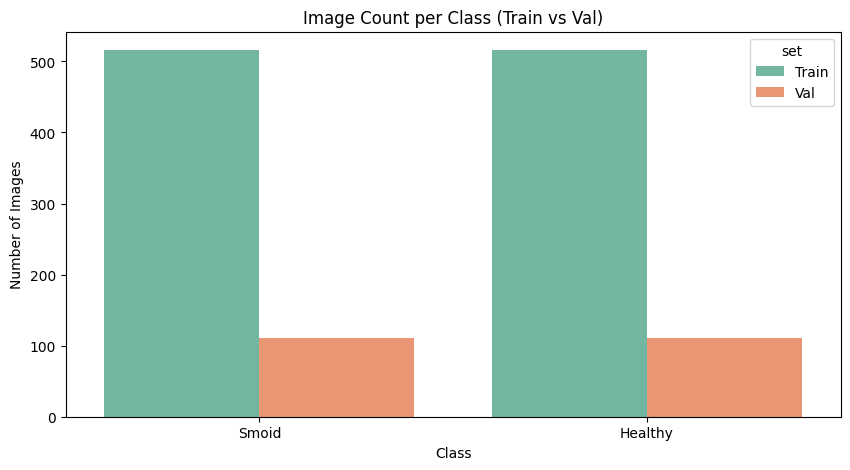

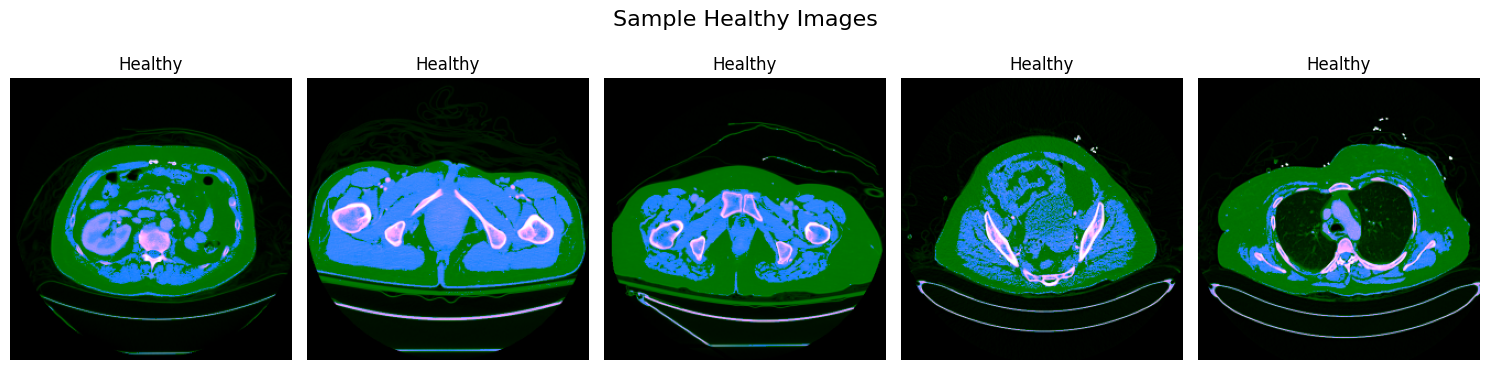

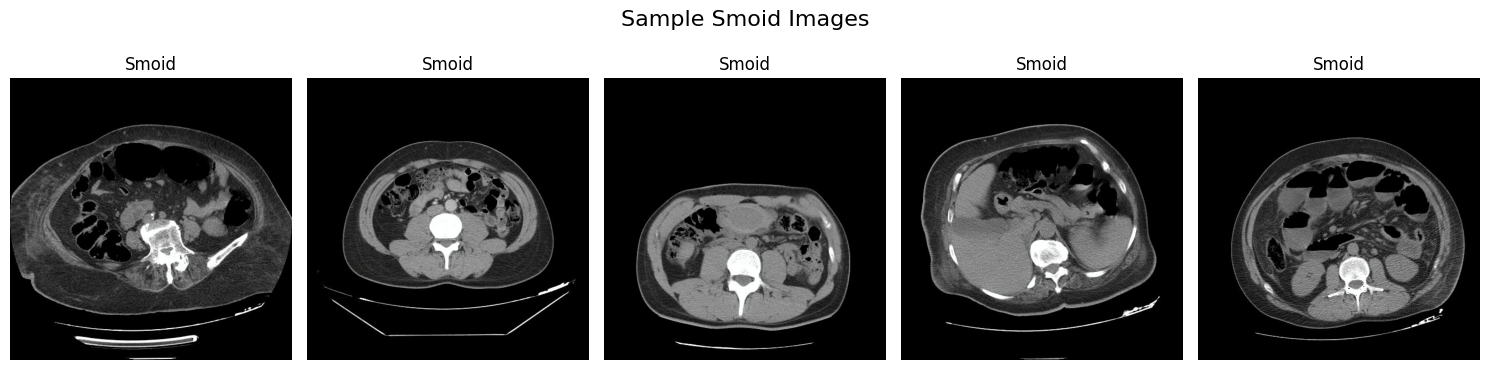

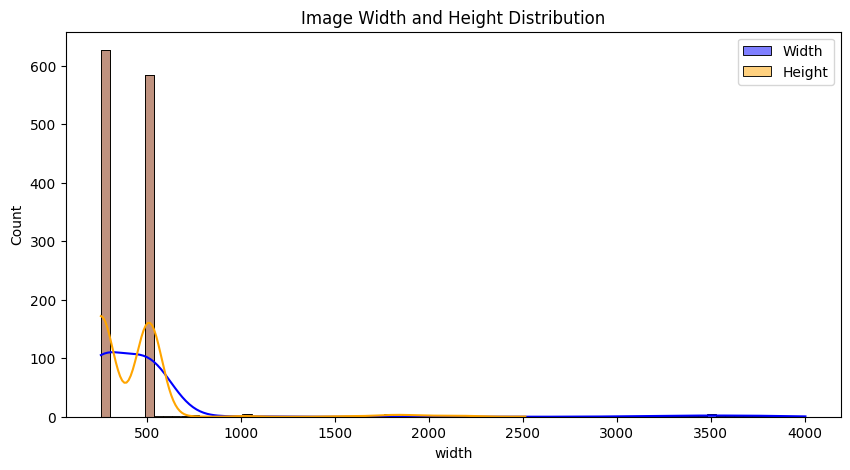

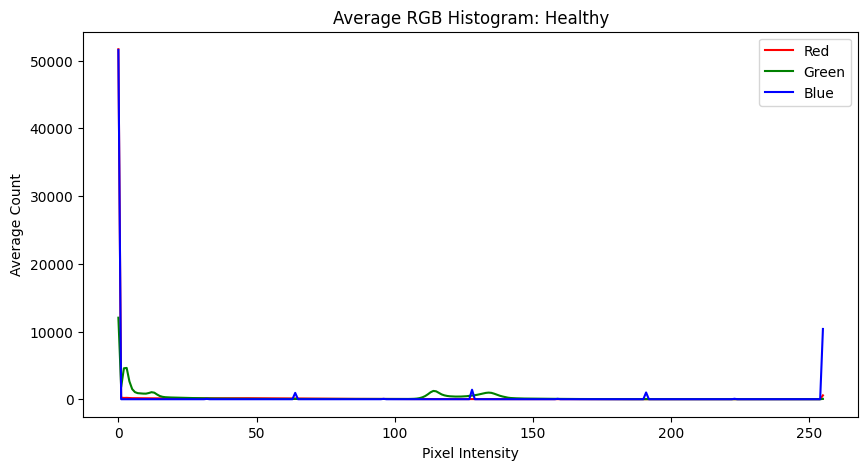

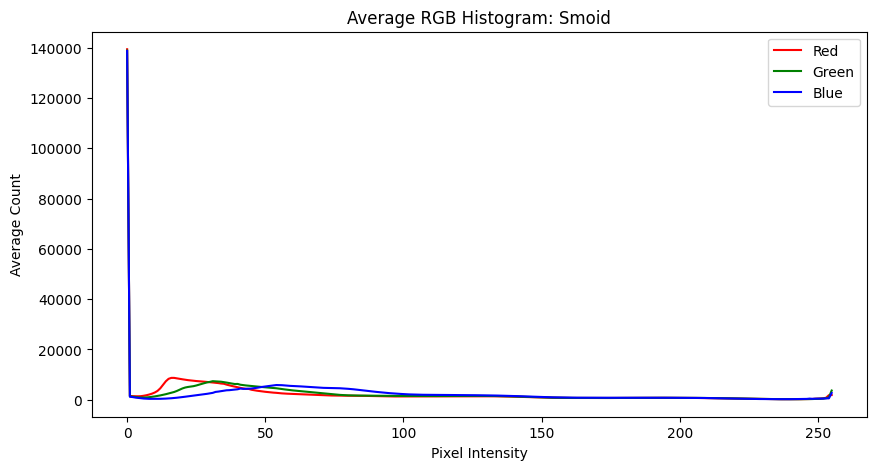

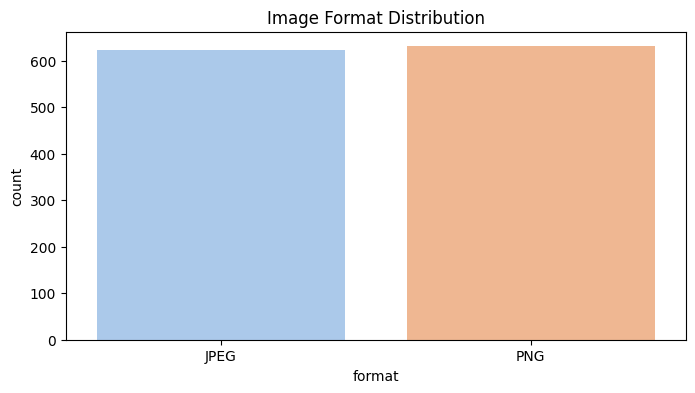

Top image resolutions:
    Width  Height  Count
0    256     256    627
1    512     512    585
2   1024    1024      4
3    734     734      1
4    722     556      1
Target Image Found:
                                                    path  label  set  width  \
1068  /content/sg11/sgmoidAI/sgmoidAI/Val/Smoid/pati...  Smoid  Val   3618   

      height format  
1068    2514   JPEG  


In [15]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import pandas as pd
import os

# Updated paths
train_healthy_path = '/content/sg11/sgmoidAI/sgmoidAI/Train/Healthy/'
train_smoid_path = '/content/sg11/sgmoidAI/sgmoidAI/Train/Smoid/'
val_healthy_path = '/content/sg11/sgmoidAI/sgmoidAI/Val/Healthy/'
val_smoid_path = '/content/sg11/sgmoidAI/sgmoidAI/Val/Smoid/'
test_path = '/content/sg11/sgmoidAI/sgmoidAI/Test/'

# Print image counts
print('Total training Healthy images:', len(os.listdir(train_healthy_path)))
print('Total training Smoid images:', len(os.listdir(train_smoid_path)))
print('Total validation Healthy images:', len(os.listdir(val_healthy_path)))
print('Total validation Smoid images:', len(os.listdir(val_smoid_path)))
print('Total test images:', len(os.listdir(test_path)))


# Set dataset paths
train_dir = '/content/sg11/sgmoidAI/sgmoidAI/Train'
val_dir = '/content/sg11/sgmoidAI/sgmoidAI/Val'

# Function to load image paths with labels
def get_image_paths(data_dir):
    data = []
    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)
        if os.path.isdir(label_path):
            for img_name in os.listdir(label_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(label_path, img_name)
                    data.append({'path': img_path, 'label': label})
    return pd.DataFrame(data)

# Load train and val image paths
df_train = get_image_paths(train_dir)
df_val = get_image_paths(val_dir)

# Add set labels
df_train['set'] = 'Train'
df_val['set'] = 'Val'

# Combine into one dataframe
df = pd.concat([df_train, df_val]).reset_index(drop=True)

# Print info
print("Total images:", len(df))
print(df['label'].value_counts())

# 1. Plot image count per class
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='label', hue='set', palette='Set2')
plt.title("Image Count per Class (Train vs Val)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# 2. Display sample images from each class
def show_sample_images(df_subset, title, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 4))
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes):
        img = Image.open(df_subset.iloc[i]['path'])
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(df_subset.iloc[i]['label'])
    plt.tight_layout()
    plt.show()

# Show Healthy and Sigmoid examples
show_sample_images(df[df['label'] == 'Healthy'].reset_index(), "Sample Healthy Images")
show_sample_images(df[df['label'] == 'Smoid'].reset_index(), "Sample Smoid Images")

# 3. Analyze image sizes and formats
def analyze_image_sizes(df):
    widths, heights, formats = [], [], []
    for path in df['path']:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            formats.append(img.format)
    df['width'] = widths
    df['height'] = heights
    df['format'] = formats
    return df

df = analyze_image_sizes(df)

# Plot image size distribution
plt.figure(figsize=(10,5))
sns.histplot(df['width'], kde=True, color='blue', label='Width')
sns.histplot(df['height'], kde=True, color='orange', label='Height')
plt.title("Image Width and Height Distribution")
plt.legend()
plt.show()

# 4. Plot average RGB histograms for each class
def plot_avg_rgb_histogram(df_subset, title):
    r_total, g_total, b_total = np.zeros(256), np.zeros(256), np.zeros(256)
    for path in df_subset['path']:
        img = Image.open(path).convert('RGB')
        r, g, b = img.split()
        r_total += np.array(r.histogram())
        g_total += np.array(g.histogram())
        b_total += np.array(b.histogram())

    total = len(df_subset)
    r_total /= total
    g_total /= total
    b_total /= total

    plt.figure(figsize=(10, 5))
    plt.plot(r_total, color='red', label='Red')
    plt.plot(g_total, color='green', label='Green')
    plt.plot(b_total, color='blue', label='Blue')
    plt.title(f"Average RGB Histogram: {title}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Average Count")
    plt.legend()
    plt.show()

plot_avg_rgb_histogram(df[df['label'] == 'Healthy'], "Healthy")
plot_avg_rgb_histogram(df[df['label'] == 'Smoid'], "Smoid")

# 5. Check image format distribution
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='format', hue='format', palette='pastel', legend=False)
plt.title("Image Format Distribution")
plt.show()

# 6. Show top image resolutions
resolutions = df[['width', 'height']].value_counts().reset_index()
resolutions.columns = ['Width', 'Height', 'Count']
print("Top image resolutions:\n", resolutions.head())

# 7. Optional - Locate specific image
target_img = df[df['path'].str.contains('patient \(95\)C.jpg')]
print("Target Image Found:\n", target_img)


In [16]:
!pip install optuna torch torchvision numpy scikit-learn matplotlib


In [17]:
!pip install optuna


In [27]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 22.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is inco

In [20]:
!pip install keras


## **MobileNetV2**

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directories
train_dir = '/content/sg11/sgmoidAI/sgmoidAI/Train/'
val_dir = '/content/sg11/sgmoidAI/sgmoidAI/Val/'

# Parameters
img_size = 224
batch_size = 32
epochs = 4 # ✅ Set to 3 as requested
input_shape = (img_size, img_size, 3)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'

)

val_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb'  # Use 'grayscale' if your images are grayscale
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb'
)

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# Load MobileNetV2 base model
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
base_model.trainable = False  # Freeze base

# Build model
inputs = Input(shape=input_shape)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,  # ✅ Only 3 epochs
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

# Evaluate
loss, accuracy = model.evaluate(val_generator)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


Found 1032 images belonging to 2 classes.
Found 222 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5545 - loss: 3.0875

32/32 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.5670 - loss: 3.0632 - val_accuracy: 0.7188 - val_loss: 2.9213
Epoch 2/4
 1/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4688 - loss: 3.0716

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 551ms/step - accuracy: 0.4688 - loss: 3.0716 - val_accuracy: 0.6979 - val_loss: 2.9246
Epoch 3/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6568 - loss: 2.9274

32/32 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.6560 - loss: 2.9282 - val_accuracy: 0.8177 - val_loss: 2.8079
Epoch 4/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 417ms/step - accuracy: 0.6875 - loss: 2.8921 - val_accuracy: 0.8177 - val_loss: 2.8206
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8153 - loss: 2.8199
Validation Accuracy: 81.53%


In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the test generator (make sure to adjust the path to your test data)
test_datagen = ImageDataGenerator(rescale=1./255)  # Rescale pixel values to [0, 1]
test_generator = test_datagen.flow_from_directory(
    '/content/sg11/sgmoidAI/sgmoidAI/Val/',  # Replace with the path to your validation or test data
    target_size=(224, 224),  # Adjust to your model's expected input size
    batch_size=32,
    class_mode='binary',  # Binary classification (Healthy vs Sigmoid)
    shuffle=False  # Don't shuffle if you want to match predictions to ground truth
)


Found 222 images belonging to 2 classes.


7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Confusion Matrix:
[[ 77  34]
 [  7 104]]


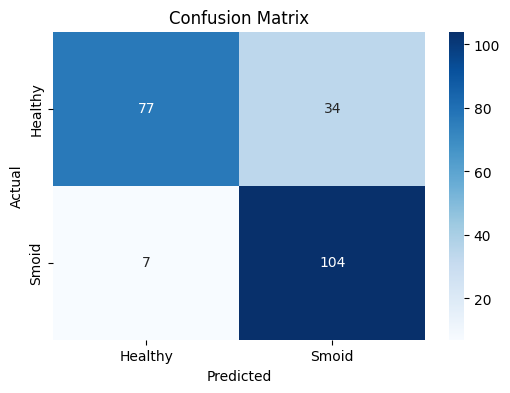

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.92      0.69      0.79       111
       Smoid       0.75      0.94      0.84       111

    accuracy                           0.82       222
   macro avg       0.84      0.82      0.81       222
weighted avg       0.84      0.82      0.81       222



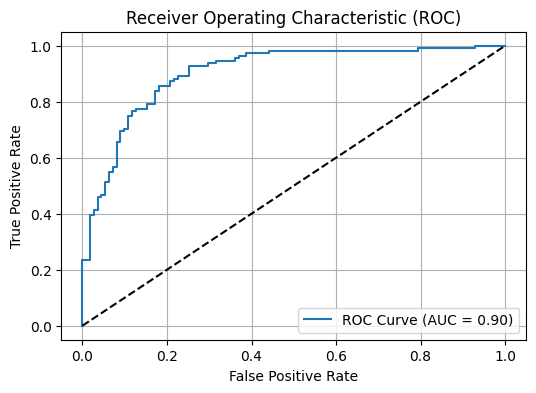

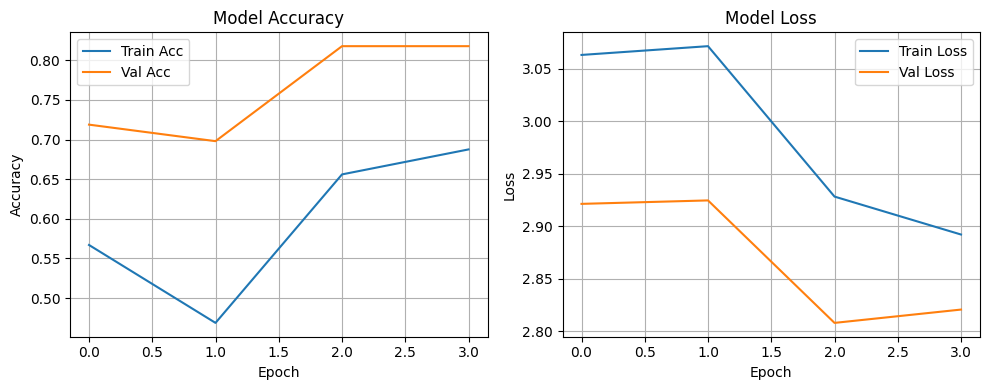

In [30]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions and true labels
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype(int)

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Smoid'],
            yticklabels=['Healthy', 'Smoid'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. Classification Report
report = classification_report(y_true, y_pred_classes, target_names=['Healthy', 'Smoid'])
print("Classification Report:")
print(report)

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 4. Training History Plot (optional – requires `history` object)
if 'history' in globals():
    # Accuracy
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


### **CNN with RGB Superposition**

Found 1032 images belonging to 2 classes.
Found 222 images belonging to 2 classes.


/tmp/ipykernel_1655/1595778316.py:58: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(include_top=False, weights='imagenet', input_tensor=input_tensor)


Epoch 1/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.5116 - auc: 0.5143 - loss: 0.8596 - val_accuracy: 0.5315 - val_auc: 0.5772 - val_loss: 0.7133 - learning_rate: 1.0000e-04
Epoch 2/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.6182 - auc: 0.6724 - loss: 0.6785 - val_accuracy: 0.7387 - val_auc: 0.8205 - val_loss: 0.5711 - learning_rate: 1.0000e-04
Epoch 3/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.7364 - auc: 0.8155 - loss: 0.5232 - val_accuracy: 0.8739 - val_auc: 0.9328 - val_loss: 0.4668 - learning_rate: 1.0000e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8739 - auc: 0.9328 - loss: 0.4668
Validation Accuracy: 87.39%
Validation AUC: 0.9328
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


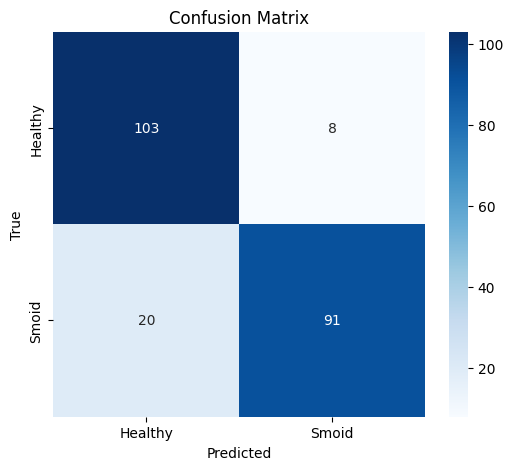

Classification Report:
               precision    recall  f1-score   support

     Healthy       0.84      0.93      0.88       111
       Smoid       0.92      0.82      0.87       111

    accuracy                           0.87       222
   macro avg       0.88      0.87      0.87       222
weighted avg       0.88      0.87      0.87       222



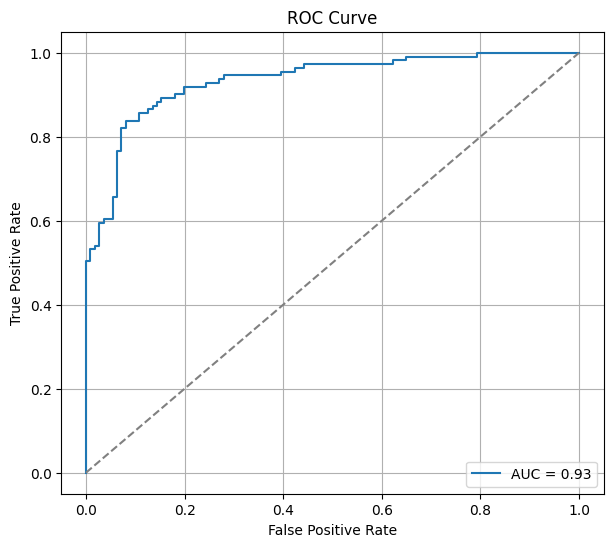

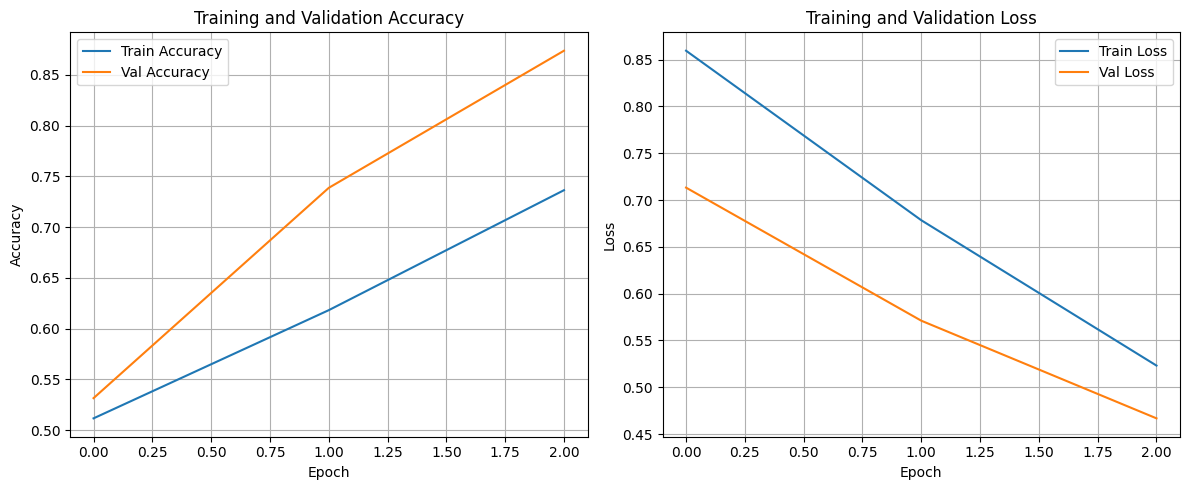

,precision,recall,f1-score,support
Healthy,0.837,0.928,0.880,111.000
Smoid,0.919,0.820,0.867,111.000
accuracy,0.874,0.874,0.874,0.874
macro avg,0.878,0.874,0.874,222.000
weighted avg,0.878,0.874,0.874,222.000


In [31]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Paths
train_dir = '/content/sg11/sgmoidAI/sgmoidAI/Train/'
val_dir = '/content/sg11/sgmoidAI/sgmoidAI/Val/'

# Data generators
target_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

# Compute class weights
labels = train_generator.classes
class_weights = dict(enumerate(compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)))

# Model building
input_tensor = Input(shape=(224, 224, 3))
mobilenet = MobileNetV2(include_top=False, weights='imagenet', input_tensor=input_tensor)
mobilenet.trainable = False

x = mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_tensor, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# Training
epochs = 3
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks
)

# Evaluation
val_loss, val_accuracy, val_auc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation AUC: {val_auc:.4f}")

# Predictions
val_generator.reset()
pred_probs = model.predict(val_generator)
pred_classes = (pred_probs > 0.5).astype(int).reshape(-1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
report = classification_report(true_classes, pred_classes, target_names=class_labels, output_dict=True)
report_table = classification_report(true_classes, pred_classes, target_names=class_labels)
print("Classification Report:\n", report_table)

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(true_classes, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluation Table
import pandas as pd
df_report = pd.DataFrame(report).transpose()
display(df_report.round(3))
